# Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2025-10-02 09:19:12.631297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759396752.658172    1009 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759396752.666127    1009 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load dataset

In [2]:
train_dir = "/kaggle/input/standard-ocr-dataset/data/training_data"
test_dir  = "/kaggle/input/standard-ocr-dataset/data/testing_data"

# Data Augmentation

In [3]:
img_height, img_width = 32, 32
batch_size = 64

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    validation_split=0.1
)

# Training Data Loader

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

Found 18576 images belonging to 36 classes.


# Validation Data Loader

In [6]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

Found 2052 images belonging to 36 classes.


# Test Data Loader

In [7]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 1008 images belonging to 36 classes.


In [8]:
num_classes = len(train_generator.class_indices)
print("Jumlah kelas:", num_classes)
print("Mapping kelas:", train_generator.class_indices)

Jumlah kelas: 36
Mapping kelas: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'E': 14, 'F': 15, 'G': 16, 'H': 17, 'I': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'O': 24, 'P': 25, 'Q': 26, 'R': 27, 'S': 28, 'T': 29, 'U': 30, 'V': 31, 'W': 32, 'X': 33, 'Y': 34, 'Z': 35}


# Build CNN Model

In [9]:
model = Sequential([    
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-02 09:19:36.019970: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,148 (914.64 KB)

 Trainable params: 233,700 (912.89 KB)

 Non-trainable params: 448 (1.75 KB)

# Callback

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_ocr_cnn.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Training Model

In [12]:
history = model.fit(
    train_generator,
    epochs=30,   # bisa ditambah kalau GPU kuat
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3809 - loss: 2.4781
Epoch 1: val_accuracy improved from -inf to 0.04776, saving model to best_ocr_cnn.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.3816 - loss: 2.4748 - val_accuracy: 0.0478 - val_loss: 5.9915 - learning_rate: 0.0010
Epoch 2/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8023 - loss: 0.6405
Epoch 2: val_accuracy improved from 0.04776 to 0.86598, saving model to best_ocr_cnn.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step - accuracy: 0.8024 - loss: 0.6403 - val_accuracy: 0.8660 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 3/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8587 - loss: 0.4480
Epoch 3: val_accuracy improved from 0.86598 to 0.93275, saving model to best_ocr_cnn.h5
291/291 ━━━━━━━━━━━━━━━━━━━━ 32s 110ms/step - accuracy: 0.8588 - loss: 0.4480 - val_accuracy: 0.9327 - val_loss: 0.1823 - learning_rate: 0.0010
Epoch 4/30
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 

# Visualisasi Training

In [20]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

## Plot akurasi

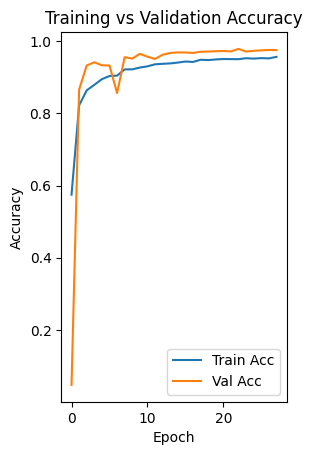

In [14]:
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

## Plot loss

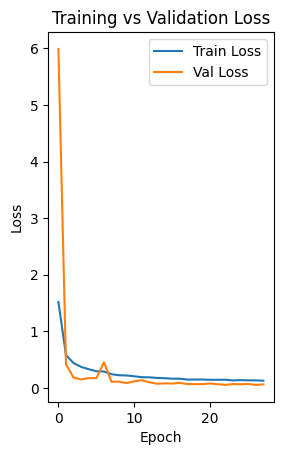

In [15]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Random Sample Prediction

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


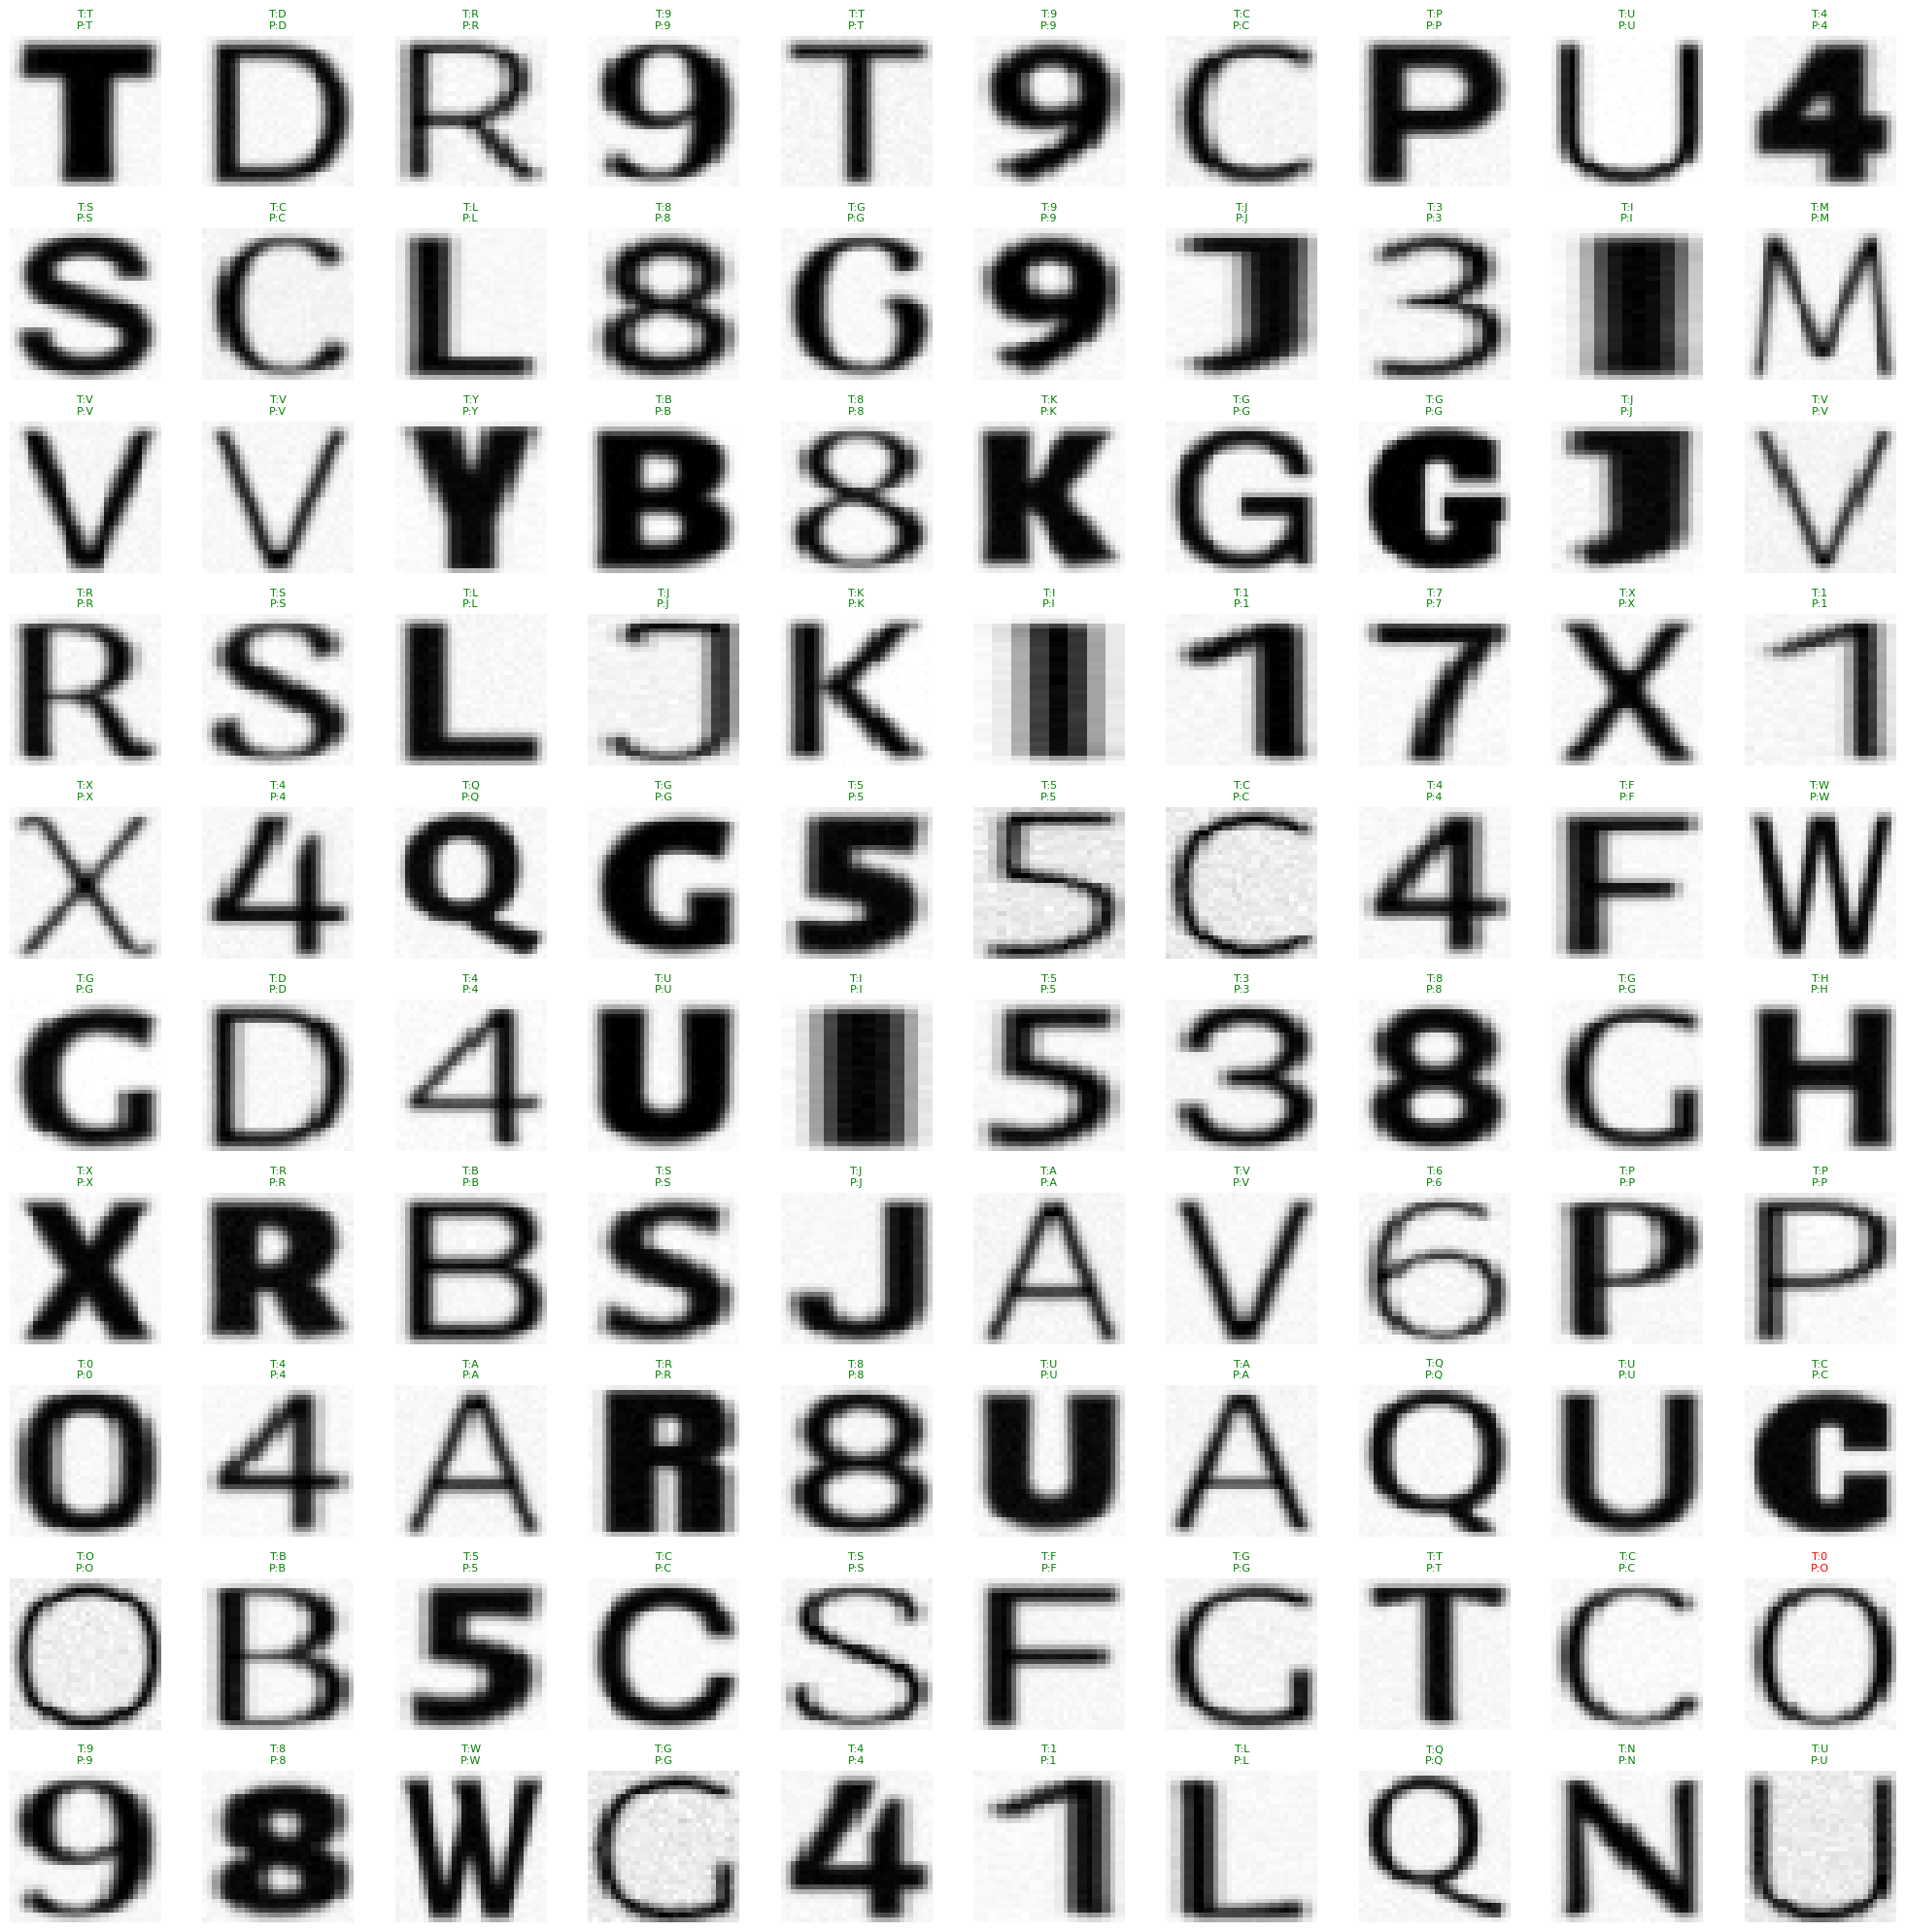

In [19]:
X_test, y_test = next(iter(test_generator))
for i in range(len(test_generator) - 1):
    x, y = next(iter(test_generator))
    X_test = np.concatenate([X_test, x])
    y_test = np.concatenate([y_test, y])

pred_probs = model.predict(X_test)
predicted_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test, axis=1)

class_labels = list(test_generator.class_indices.keys())
predicted_chars = [class_labels[i] for i in predicted_labels]

random_indices = random.sample(range(len(X_test)), 100)

fig, axes = plt.subplots(10, 10, figsize=(20, 20))

for idx, ax in zip(random_indices, axes.flatten()):
    ax.imshow(X_test[idx].reshape(img_height, img_width), cmap='gray')
    true_label = class_labels[true_labels[idx]]
    pred_label = predicted_chars[idx]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Evaluasi Model

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9434 - loss: 0.0896

Akurasi di Test Set: 97.82%
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.39      0.51        28
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        28
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00        28
           8       1.00      1.00      1.00        28
           9       1.00      1.00      1.00        28
           A       1.00      1.00      1.00        28
           B       1.00      1.00      1.00        28
           C       1.00      1.00      1.00        28
           D       1.00      1.00      1.00        28
           E       0.9

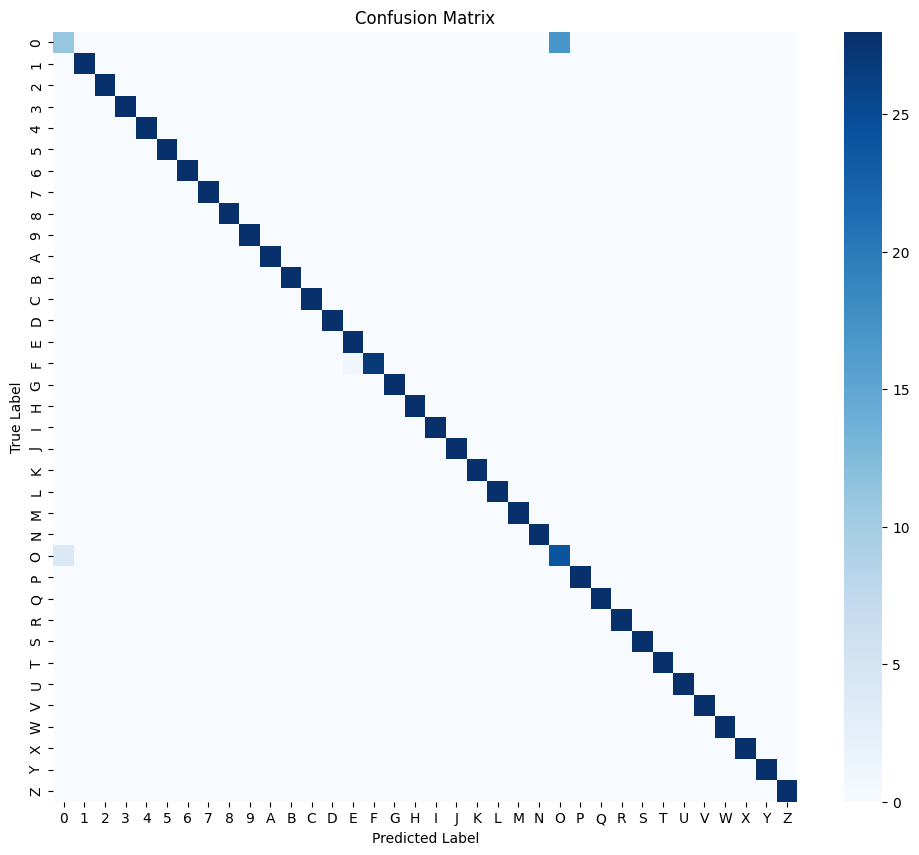

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nAkurasi di Test Set: {test_acc*100:.2f}%")

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(test_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()